In [2]:
%matplotlib inline

In [ ]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 10),
        control_mode=CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.5,
        desired_position=0.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")

mode_segments = parse_mixed_csv("c:\\Users\\labuser\\Desktop\\unicycle_project_umich\\LOGS\\ValidLogs\\log_2026-04-01_14-20-46.533.csv")
data = None
for item in mode_segments:
    if item['mode'] == 'velocity':
        data = item['data'] # the last veloicity 

if data is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No velocity data found in the CSV file.")

realdata = getVelocityFromData(data)
print(realdata)

def penaltyFunc(resultStorage):
    error = 0.0

    if realdata is None or len(realdata) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[2]  #  third column is velocity


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/10 for t in range(0,100)] # 0 to 10 seconds with 0.01s intervals

    for t in times:
        closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
        closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

        #print(closest_time_simu, closest_time_real)

        # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

        error += (closest_time_simu[1] - closest_time_real[1]) ** 2

    return error / len(times)    



best_params = tune_parameters(paramDict =  {'B': 0.009355712797712799, 'B_0': 0.0011494577536160012, 'mu_rolling': 0.0025357458535808356, 'I': 0.6385543701447575},
                                simulation=simulate,
                                realdata=realdata,
                                ax_real_name="Real Velocity Data",
                                ax_try_name="Simulated Velocity Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 2, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=50,
                                )

It's better to use all the data we tested multiple times for velocity.

Best Score: 0.000954
Best Parameters: {'B': 0.3412352909215786, 'B_0': 0.011337090552689628, 'mu_rolling': 0.009937861087525632, 'm_w': 6.509289047678268, 'm': 0.7907109523217312}


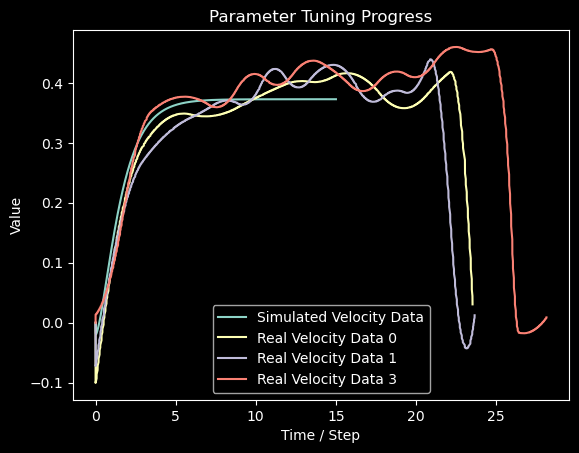

In [ ]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE
from Parameters import params


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 15),
        control_mode=CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.5,
        desired_position=0.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")
filenames = [
    '/Users/gaoshenghan/Desktop/stm32/stm32wb55rg_canspi_to_arduino/LOGS/ValidLogs/V0.5x3.csv',
    '/Users/gaoshenghan/Desktop/stm32/stm32wb55rg_canspi_to_arduino/LOGS/ValidLogs/V0.5x3(2).csv',
]

dataList = []

for file in filenames:
    mode_segments = parse_mixed_csv(file)

    for item in mode_segments:
        if item['mode'] == 'velocity':
        
            dataList.append(item['data'])        

if dataList is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No position data found in the CSV file.")

realdataList = [(i, getVelocityFromData(val)) for i, val in enumerate(dataList)]

# remove faulty data
faultylist = [7,4,2,5,6]
realdataList = [data for i, data in enumerate(realdataList) if i not in faultylist]


def penaltyFunc(resultStorage):
    error = 0.0

    if realdataList is None or len(realdataList) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[2]  #  third column is velocity


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/10 for t in range(0,150)] 

    for i, realdata in realdataList:

        for t in times:
            closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
            closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

            #print(closest_time_simu, closest_time_real)

            # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

            error += (closest_time_simu[1] - closest_time_real[1]) ** 2

    return error / (len(times) * len(realdataList))

params.I = 0.104

# velcity data {'B': 0.29534719835953205, 'B_0': 0.012007420032393943, 'mu_rolling': 0.010143346358048193, 'm_w': 6.555652034148903, 'm': 0.7443479658510976}

best_params = tune_parameters(paramDict =  {'B': 0.3412352909215786, 'B_0': 0.011337090552689628, 'mu_rolling': 0.009937861087525632, 'm_w': 6.509289047678268, 'm': 0.7907109523217312},
                                simulation=simulate,
                                realdata=realdataList,
                                ax_real_name="Real Velocity Data",
                                ax_try_name="Simulated Velocity Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 2, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=50,
                                )

- Also the same param in position mode

Best Score: 0.013032
Best Parameters: {'B': 0.3412352909215786, 'B_0': 0.011337090552689628, 'mu_rolling': 0.009937861087525632, 'm_w': 6.509289047678268, 'm': 0.7907109523217312}


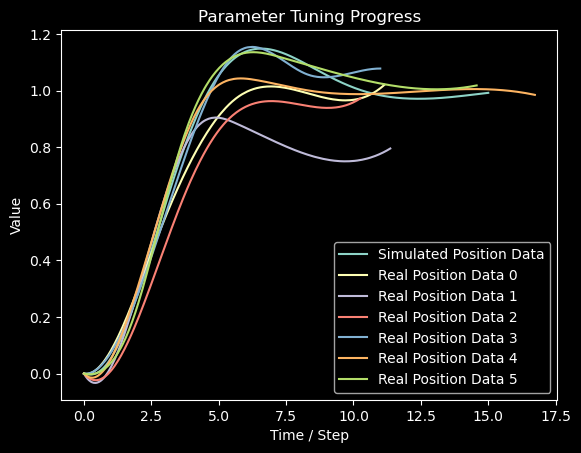

In [26]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE
from Parameters import params


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 15),
        control_mode=CONTROL_MODE.POSITION,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.0,
        desired_position=1.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")
filenames = [
    '/Users/gaoshenghan/Desktop/stm32/stm32wb55rg_canspi_to_arduino/LOGS/ValidLogs/P1.0x3.csv',
    '/Users/gaoshenghan/Desktop/stm32/stm32wb55rg_canspi_to_arduino/LOGS/ValidLogs/P1.0x3(2).csv',
]

dataList = []

for file in filenames:
    mode_segments = parse_mixed_csv(file)

    for item in mode_segments:
        if item['mode'] == 'position':
        
            dataList.append(item['data'])        

if dataList is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No position data found in the CSV file.")

realdataList = [(i, getPositionFromData(val)) for i, val in enumerate(dataList)]

# remove faulty data
# faultylist = [7,4,2,5,6]
# realdataList = [data for i, data in enumerate(realdataList) if i not in faultylist]


def penaltyFunc(resultStorage):
    error = 0.0

    if realdataList is None or len(realdataList) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[1]  #  third column is velocity.. for position data, it's at index 1, second column


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/10 for t in range(0,100)] 

    for i, realdata in realdataList:

        for t in times:
            closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
            closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

            #print(closest_time_simu, closest_time_real)

            # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

            error += (closest_time_simu[1] - closest_time_real[1]) ** 2

    return error / (len(times) * len(realdataList))

params.I = 0.104

# velcity data {'B': 0.29534719835953205, 'B_0': 0.012007420032393943, 'mu_rolling': 0.010143346358048193, 'm_w': 6.555652034148903, 'm': 0.7443479658510976}

best_params = tune_parameters(paramDict =  {'B': 0.3412352909215786, 'B_0': 0.011337090552689628, 'mu_rolling': 0.009937861087525632, 'm_w': 6.509289047678268, 'm': 0.7907109523217312},
                                simulation=simulate,
                                realdata=realdataList,
                                ax_real_name="Real Position Data",
                                ax_try_name="Simulated Position Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 1, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=0,
                                )